# 03 - CNN simples (baseline)

**Objetivo:** treinar uma CNN pequena, do zero, só para servir de **ponto de comparação**. Mais à frente, com a ResNet18 pré-treinada, vamos ver se ela realmente melhora o resultado, ou se toda essa complexidade extra não valeu a pena.

Neste notebook avaliamos só na **validação**. O conjunto de teste fica guardado para a comparação final entre os modelos, assim não "colamos" olhando o teste enquanto ainda estamos ajustando as coisas.

**Como uma CNN aprende, em 4 passos simples:**
1. Ela recebe um grupo de imagens e tenta adivinhar (`NORMAL` ou `PNEUMONIA`).
2. A gente compara o palpite com a resposta certa e calcula a **perda** (um número que mede o quanto ela errou).
3. O modelo ajusta os seus números internos (os "pesos") para errar um pouco menos da próxima vez. Esse ajuste automático tem um nome técnico, *backpropagation*, mas o que importa é a ideia: aprender com o próprio erro.
4. Repete isso por várias **épocas** (uma época = passar por todas as imagens de treino uma vez).

## 1. Preparação

In [1]:
import sys
sys.path.append("..")

from pathlib import Path

import matplotlib.pyplot as plt
import torch
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

from src import dados, modelos, treino

torch.manual_seed(42)               # resultados reproduzíveis

PASTA_FIGURAS = Path("..") / "reports" / "figures"
PASTA_MODELOS = Path("..") / "models"

dispositivo = treino.escolher_dispositivo()
print("Dispositivo:", dispositivo)

Dispositivo: mps


In [2]:
loaders, tabelas = dados.criar_dataloaders(tamanho_lote=32)
pesos_classe = dados.pesos_de_classe(tabelas["treino"])
print("Pesos de classe:", dict(zip(dados.CLASSES, pesos_classe.tolist())))

Pesos de classe: {'NORMAL': 1.9458955526351929, 'PNEUMONIA': 0.6729032397270203}


## 2. O modelo

A `CNNSimples` (em [`src/modelos.py`](../src/modelos.py)) tem 4 blocos convolucionais. Cada bloco detecta padrões na imagem e reduz o seu tamanho pela metade, enquanto aumenta a quantidade de "mapas de características": 16, 32, 64 e 128.

In [3]:
modelo = modelos.CNNSimples()
print(modelo)
print()
print(f"Total de parâmetros (pesos ajustáveis): {sum(p.numel() for p in modelo.parameters()):,}")

CNNSimples(
  (extrator): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0): C

## 3. Treino

Configurações:
- **12 épocas** (12 voltas completas pelas imagens de treino).
- **Adam**, com taxa de aprendizado `0.001`: Adam é o algoritmo que decide o tamanho de cada ajuste nos pesos; a taxa de aprendizado é esse "tamanho do passo" — menor é mais lento e estável, maior é mais rápido mas mais arriscado.
- **Perda com pesos de classe:** errar uma imagem NORMAL (a classe rara) pesa mais no cálculo do erro, para o modelo não ignorá-la.
- Os melhores pesos (os da época com menor perda na validação) são salvos em `models/cnn_simples.pt`.

> Esta célula demora (na casa de 15 a 20 minutos). A parte lenta é carregar e transformar as imagens, não o cálculo em si.

In [4]:
historico = treino.treinar(
    modelo, loaders, pesos_classe,
    epocas=12,
    taxa_aprendizado=1e-3,
    caminho_pesos=PASTA_MODELOS / "cnn_simples.pt",
    dispositivo=dispositivo,
)

Época  1/12 | treino: perda 0.459 acc 0.789 | val: perda 0.292 acc 0.903 recall 0.894 | 92s  <- melhor até agora


Época  2/12 | treino: perda 0.353 acc 0.853 | val: perda 0.333 acc 0.852 recall 0.961 | 92s


Época  3/12 | treino: perda 0.315 acc 0.872 | val: perda 0.273 acc 0.900 recall 0.876 | 1140s  <- melhor até agora


Época  4/12 | treino: perda 0.275 acc 0.887 | val: perda 0.215 acc 0.925 recall 0.907 | 1535s  <- melhor até agora


Época  5/12 | treino: perda 0.260 acc 0.899 | val: perda 0.558 acc 0.823 recall 0.769 | 4594s


...

Época  8/12 | treino: perda 0.229 acc 0.908 | val: perda 0.214 acc 0.921 recall 0.898 | 6516s


Época  9/12 | treino: perda 0.200 acc 0.923 | val: perda 0.415 acc 0.865 recall 0.819 | 1978s


Época 10/12 | treino: perda 0.198 acc 0.926 | val: perda 0.111 acc 0.963 recall 0.982 | 2388s  <- melhor até agora


Época 11/12 | treino: perda 0.202 acc 0.921 | val: perda 0.139 acc 0.947 recall 0.945 | 1414s


Época 12/12 | treino: perda 0.179 acc 0.935 | val: perda 0.658 acc 0.721 recall 0.625 | 2217s


## 4. Curvas de aprendizado

Comparar treino e validação ao longo das épocas ajuda a detectar **overfitting**: quando o desempenho no treino continua melhorando, mas o da validação para de melhorar ou piora, o modelo está decorando o treino em vez de aprender o padrão geral.

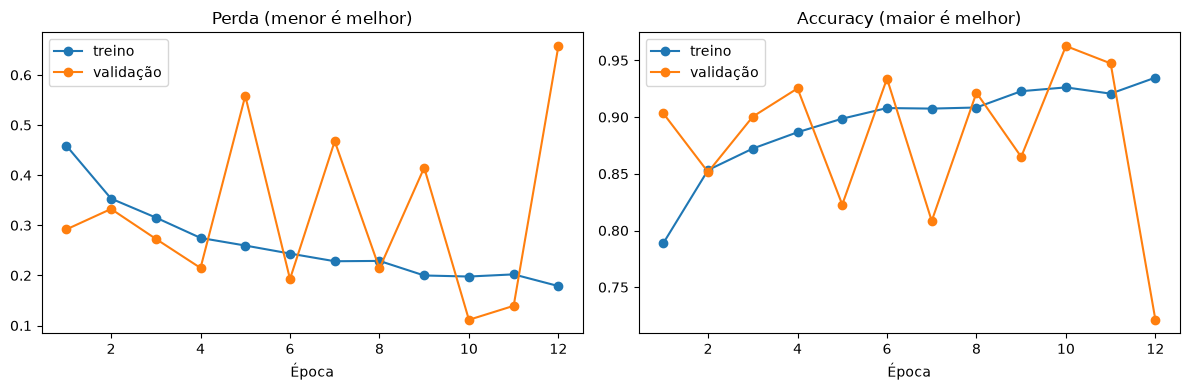

In [5]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))

eixos[0].plot(historico["epoca"], historico["perda_treino"], marker="o", label="treino")
eixos[0].plot(historico["epoca"], historico["perda_val"], marker="o", label="validação")
eixos[0].set_title("Perda (menor é melhor)")

eixos[1].plot(historico["epoca"], historico["acc_treino"], marker="o", label="treino")
eixos[1].plot(historico["epoca"], historico["acc_val"], marker="o", label="validação")
eixos[1].set_title("Accuracy (maior é melhor)")

for eixo in eixos:
    eixo.set_xlabel("Época")
    eixo.legend()
plt.tight_layout()
fig.savefig(PASTA_FIGURAS / "03_cnn_simples_curvas.png", dpi=120)
plt.show()

## 5. Desempenho na validação

Usamos os melhores pesos (já carregados ao final do treino). Métricas, com PNEUMONIA como a classe que queremos encontrar:
- **Recall:** dos pacientes com pneumonia, quantos o modelo encontrou. É a métrica principal, porque deixar passar uma pneumonia (falso negativo) é o erro mais grave.
- **Precisão:** das vezes que o modelo disse "pneumonia", quantas estavam certas.
- **F1:** equilíbrio entre recall e precisão.

In [6]:
criterio = torch.nn.CrossEntropyLoss(weight=pesos_classe.to(dispositivo))
_, rotulos_val, previsoes_val = treino.avaliar(modelo, loaders["val"], criterio, dispositivo)

print(classification_report(rotulos_val, previsoes_val, target_names=dados.CLASSES, digits=3))

              precision    recall  f1-score   support

      NORMAL      0.946     0.907     0.926       269
   PNEUMONIA      0.968     0.982     0.975       775

    accuracy                          0.963      1044
   macro avg      0.957     0.944     0.951      1044
weighted avg      0.962     0.963     0.962      1044



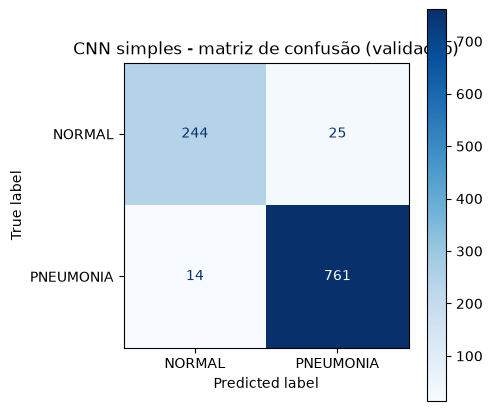

In [7]:
fig, eixo = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    rotulos_val, previsoes_val, display_labels=dados.CLASSES, cmap="Blues", ax=eixo
)
eixo.set_title("CNN simples - matriz de confusão (validação)")
plt.tight_layout()
fig.savefig(PASTA_FIGURAS / "03_cnn_simples_confusao_val.png", dpi=120)
plt.show()

## 6. Conclusões

- **Resultado na validação (melhor época, a 10ª):** 96,3% de acerto geral, e o modelo encontrou 98,2% dos casos de pneumonia (recall). O recall de NORMAL é 90,7%: o modelo erra um pouco mais ao reconhecer os normais, o que é o lado "seguro" do erro numa triagem (prefere mandar um paciente normal para revisão a deixar passar uma pneumonia).
- **Não parece estar decorando o treino (overfitting).** A accuracy no treino (cerca de 93%) ficou *abaixo* da validação, o que é esperado: no treino o modelo enfrenta imagens levemente alteradas (data augmentation) e uma técnica que o força a "esquecer" parte de si mesmo a cada passo (dropout) — as duas coisas deixam o treino mais difícil de propósito, para o modelo não decorar demais.
- **A validação oscila bastante de uma época para outra.** Por exemplo, a accuracy foi de 96% na época 10 para 72% na época 12, enquanto o treino melhorou de forma suave. Isso é comum em modelos pequenos treinados do zero. Por isso guardamos os pesos da melhor época, e não os da última.
- **Cuidado ao interpretar:** escolhemos a melhor época olhando a própria validação, então esses números são um pouco otimistas demais. O resultado mais confiável só vem do teste, lá na frente.

**Próximo passo:** treinar a ResNet18 pré-treinada, que tende a aprender de um jeito mais estável.